# Somalia workflow: Step 8: The multi-source trigger mechanism

Finalises the trigger structure agreed 2026-08-25 (updated same day after
review), superseding the staged design in notebook 10 (whose observed-SWALIM
action legs were a stand-in):

1. **Both legs are forecast-based.** SWALIM is the ground truth the mechanism
   is calibrated and validated against — never a trigger input.
2. **Pooled (station, model) pair selection with a diversity rule.** Every
   pair from the three providers — GloFAS (v5 reanalysis / v4 reforecast),
   Google GRRR and GEOGloWS — competes on one skill metric against the SWALIM
   benchmark (notebook 06's correlations). Pairs compete freely: **the same
   station may carry more than one model** (decision 2026-08-25: "I just want
   the best forecasts, as long as they're on the right basin"). Guards:
   a timing guard (best_lag >= -3 d — a model that trails the gauge by more
   burns anticipation a <= 6-day trigger cannot spare), and a **diversity
   rule**: a model absent from a window's top 8 is swapped in for the
   lowest-ranked pair when its best qualifying pair is within 0.05 rho of the
   cut (multi-model representation was an explicit stakeholder wish).
3. **Action trigger, leads <= 6 days**: per basin (Juba / Shabelle), a
   season-specific N-of-8 **pair** consensus over per-pair RP thresholds.
   Calibrated so the two basins have **equal activation probability**
   (nominal ~1-in-4.3 each) and the **overall RP (either basin) >= 3 years**.
4. **Readiness trigger, leads 7-12 days**: GloFAS-only (the only provider
   with a validatable forecast archive past 7 days).
5. Where a model has no historical forecast archive, its **reanalysis stands
   in** (the original 2026-08-25 instruction): GloFAS v5 pairs are backtested
   through the v4 reforecast with thresholds refit on v4's own climatology
   (the notebook-09 convention); GEOGloWS pairs are backtested through their
   retrospective as a lead-0 stand-in — flagged wherever it matters, since it
   cannot prove lead-time skill.
6. **Thresholds are always fitted on the indicator's own historical values**
   — we assume bias between reanalysis and forecast for ALL sources.

Inputs are the processed tables (restore with
`.venv/bin/python scripts/restore_from_blob.py`), including
`reforecast_glofas_v4_lead8_12` (built by `scripts/process_lead8_12.py`).
Outputs: `som_ms_*` tables under `processed/workflow/` and figures/JSON under
`pages/trigger/`.


In [1]:
import sys

sys.path.insert(0, "..")

import itertools
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import ocha_stratus as stratus

from src.constants import (
    SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_BAND,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import weibull_threshold

apply_chart_style()

DATA = Path("../data/processed")
FIGS = Path("../pages/trigger/figs")
FIGS.mkdir(parents=True, exist_ok=True)

def load(name):
    return pd.read_parquet(DATA / f"{name}.parquet")

def save_fig(fig, name):
    fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

YEARS = (1999, 2023)
N_YEARS = YEARS[1] - YEARS[0] + 1
YRS = set(range(YEARS[0], YEARS[1] + 1))
RP_LEVELS = [3, 4, 5, 6]     # per-pair threshold grid (RP3+ rule, nb08)
MIN_RHO = 0.5
TOP_N = 8                    # pairs per river x season
LAG_GUARD = -3               # pairs trailing the gauge by more are excluded
DIV_TOL = 0.05               # diversity rule: absent model within this of the cut
ACTION_MAX_LEAD = 6          # GloFAS "day" labels / GRRR leads (nb10 convention)
READY_LEADS = (7, 12)
GAUGE_BM = {"shabelle": "swalim_belet_weyne", "juba": "swalim_luuq"}
REF_GAUGE = {"shabelle": "belet_weyne", "juba": "luuq"}
SOURCES = ["geoglows", "glofas_v5", "google_grrr"]
SRC_LABEL = {"geoglows": "GEOGloWS", "glofas_v5": "GloFAS v5", "google_grrr": "Google GRRR"}

corr = load("workflow/som_gauge_correlations")
bench = load("workflow/som_flood_benchmark_seasonal")
dd = pd.concat(
    [load(f"discharge_daily_{s}").assign(file_source=s) for s in SOURCES],
    ignore_index=True,
)
dd["date"] = pd.to_datetime(dd["date"])
lv = load("swalim_levels")
lv["date"] = pd.to_datetime(lv["date"])
sw_th = load("swalim_thresholds").set_index("station")

def bench_years(river, season, col="flood_3yr"):
    sub = bench[(bench.river == river) & (bench.benchmark == GAUGE_BM[river])
                & (bench.season == season) & (bench[col] == 1)]
    return set(sub.year) & YRS

def basin_bench(river, col):
    return bench_years(river, "gu", col) | bench_years(river, "deyr", col)


## A. Pooled pair selection (all three providers, timing guard + diversity rule)

Rank all 18 stations x 3 models per river x season by best-lag Spearman rho
against the SWALIM reference gauge (notebook 06, P. Wairimu; the benchmark
her notebooks 01 and 05 established). Pairs compete freely — the same
station may carry two models — subject to the timing guard (lag >= -3 d).
Take the top 8 pairs, then apply the **diversity rule**: a model absent from
the window whose best qualifying pair is within 0.05 rho of the cut swaps in
for the lowest-ranked pair of the majority model.


In [2]:
cand = corr[(corr.benchmark == "swalim") & (corr.best_lag >= LAG_GUARD)
            & (corr.best_rho >= MIN_RHO)].copy()

sel_parts = []
for (river, season), g in cand.groupby(["river", "season"]):
    g = g.sort_values("best_rho", ascending=False)
    picked = g.head(TOP_N).copy()
    for src in SOURCES:
        if src in picked.source.values:
            continue
        best_pair = g[g.source == src].head(1)
        if not len(best_pair):
            print(f"  {river} {season}: {src} has no pair passing the guards")
            continue
        if best_pair.best_rho.iloc[0] >= picked.best_rho.min() - DIV_TOL:
            # drop the lowest-ranked pair of the most-represented model
            counts = picked.source.value_counts()
            majority = counts.idxmax()
            drop_idx = picked[picked.source == majority].best_rho.idxmin()
            dropped = picked.loc[drop_idx]
            picked = pd.concat([picked.drop(index=drop_idx), best_pair])
            print(f"  {river} {season}: diversity swap: {src} "
                  f"{best_pair.station.iloc[0]} (rho {best_pair.best_rho.iloc[0]:.3f}, "
                  f"lag {int(best_pair.best_lag.iloc[0]):+d}d) in for {dropped.source} "
                  f"{dropped.station} ({dropped.best_rho:.3f})")
        else:
            print(f"  {river} {season}: {src} best pair "
                  f"{best_pair.station.iloc[0]} rho {best_pair.best_rho.iloc[0]:.3f} "
                  f"is below the diversity tolerance — not included")
    sel_parts.append(picked)
sel = (pd.concat(sel_parts)
       .sort_values(["river", "season", "best_rho"], ascending=[1, 1, 0])
       .reset_index(drop=True))
print()
print(sel.groupby(["river", "season"]).source.value_counts().to_string())
dup = sel.groupby(["river", "season", "station"]).size()
print("\nstations carrying two models:",
      dup[dup > 1].reset_index()[["river", "season", "station"]].to_dict("records"))
sel


  juba deyr: google_grrr best pair dollow rho 0.598 is below the diversity tolerance — not included
  juba gu: diversity swap: geoglows dollow (rho 0.827, lag -2d) in for google_grrr dollow (0.848)
  juba gu: diversity swap: glofas_v5 luuq (rho 0.846, lag +0d) in for google_grrr jilib (0.861)
  shabelle deyr: diversity swap: geoglows belet_weyne (rho 0.752, lag +3d) in for glofas_v5 awdheegle (0.796)
  shabelle deyr: google_grrr best pair belet_weyne rho 0.635 is below the diversity tolerance — not included
  shabelle gu: geoglows has no pair passing the guards
  shabelle gu: diversity swap: glofas_v5 belet_weyne (rho 0.778, lag -3d) in for google_grrr jowhar (0.779)

river     season  source     
juba      deyr    glofas_v5      6
                  geoglows       2
          gu      google_grrr    6
                  glofas_v5      1
                  geoglows       1
shabelle  deyr    glofas_v5      7
                  geoglows       1
          gu      google_grrr    7
             

,station,source,river,season,benchmark,best_rho,best_lag,n_obs
0,dollow,glofas_v5,juba,deyr,swalim,0.868,5,2087
1,luuq,glofas_v5,juba,deyr,swalim,0.849,3,2087
2,dollow,geoglows,juba,deyr,swalim,0.828,1,2087
3,luuq,geoglows,juba,deyr,swalim,0.818,-1,2088
4,bardheere,glofas_v5,juba,deyr,swalim,0.805,0,2087
5,saakow,glofas_v5,juba,deyr,swalim,0.799,-1,2088
6,bualle,glofas_v5,juba,deyr,swalim,0.790,-2,2088
7,kaitoi,glofas_v5,juba,deyr,swalim,0.781,-3,2088
8,bardheere,google_grrr,juba,gu,swalim,0.869,-1,1999
9,saakow,google_grrr,juba,gu,swalim,0.868,-1,1999


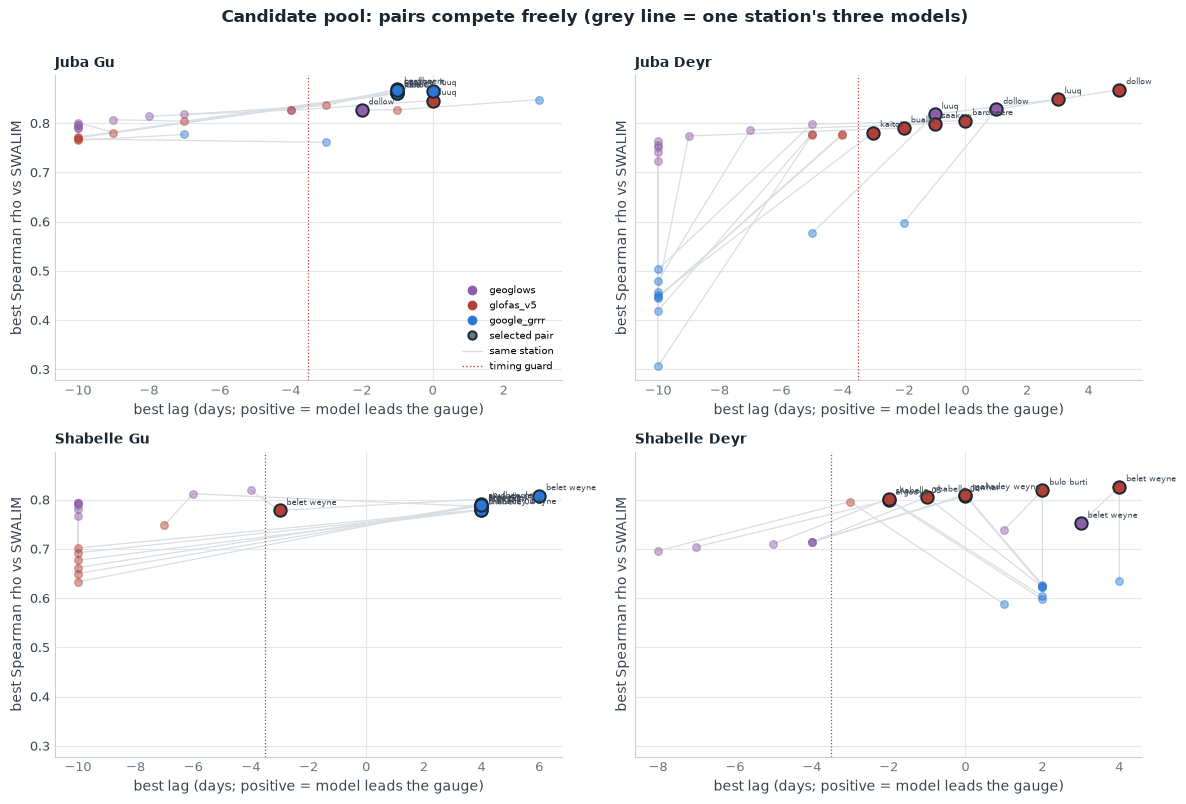

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
combos = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
for ax, (river, season) in zip(axes.ravel(), combos):
    sub = corr[(corr.benchmark == "swalim") & (corr.river == river) & (corr.season == season)]
    chosen = sel[(sel.river == river) & (sel.season == season)]
    keys = set(zip(chosen.station, chosen.source))
    for stn, g in sub.groupby("station"):
        g = g.sort_values("best_lag")
        ax.plot(g.best_lag, g.best_rho, color="#D9DEE3", lw=0.9, zorder=1)
    for src, grp in sub.groupby("source"):
        picked = grp.apply(lambda r: (r.station, r.source) in keys, axis=1)
        ax.scatter(grp[~picked].best_lag, grp[~picked].best_rho,
                   color=SOURCE_COLORS[src], alpha=0.45, s=30, zorder=3)
        ax.scatter(grp[picked].best_lag, grp[picked].best_rho,
                   color=SOURCE_COLORS[src], s=80, edgecolors=INK, linewidths=1.4,
                   zorder=4)
    for _, r in chosen.iterrows():
        ax.annotate(r.station.replace("_", " "), (r.best_lag, r.best_rho),
                    textcoords="offset points", xytext=(5, 4), fontsize=5.8,
                    color=BODY, zorder=5)
    ax.axvline(0, color=GRID, lw=0.8)
    ax.axvline(LAG_GUARD - 0.5, color="#B34036", lw=0.9, ls=":")
    ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
    ax.set_xlabel("best lag (days; positive = model leads the gauge)")
    ax.set_ylabel("best Spearman rho vs SWALIM")
    style_ax(ax, grid="y")
handles = [plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="", label=s)
           for s in SOURCES] + [
    plt.Line2D([], [], color=FAINT, marker="o", ls="", markeredgecolor=INK,
               markeredgewidth=1.4, label="selected pair"),
    plt.Line2D([], [], color="#D9DEE3", lw=1, label="same station"),
    plt.Line2D([], [], color="#B34036", lw=1, ls=":", label="timing guard"),
]
axes.ravel()[0].legend(handles=handles, fontsize=7, loc="lower right")
fig.suptitle("Candidate pool: pairs compete freely (grey line = one station's three models)",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()
save_fig(fig, "a_selection")


### The station network

The registry (18 monitoring points, GloFAS-grid-verified coordinates with
per-provider ID mappings, `src/constants.py`) and the river buffers are
Pauline Wairimu's; the map shows which model(s) carry each station in the
adopted mechanism, per season window — a second ring around a station means
it carries two models.


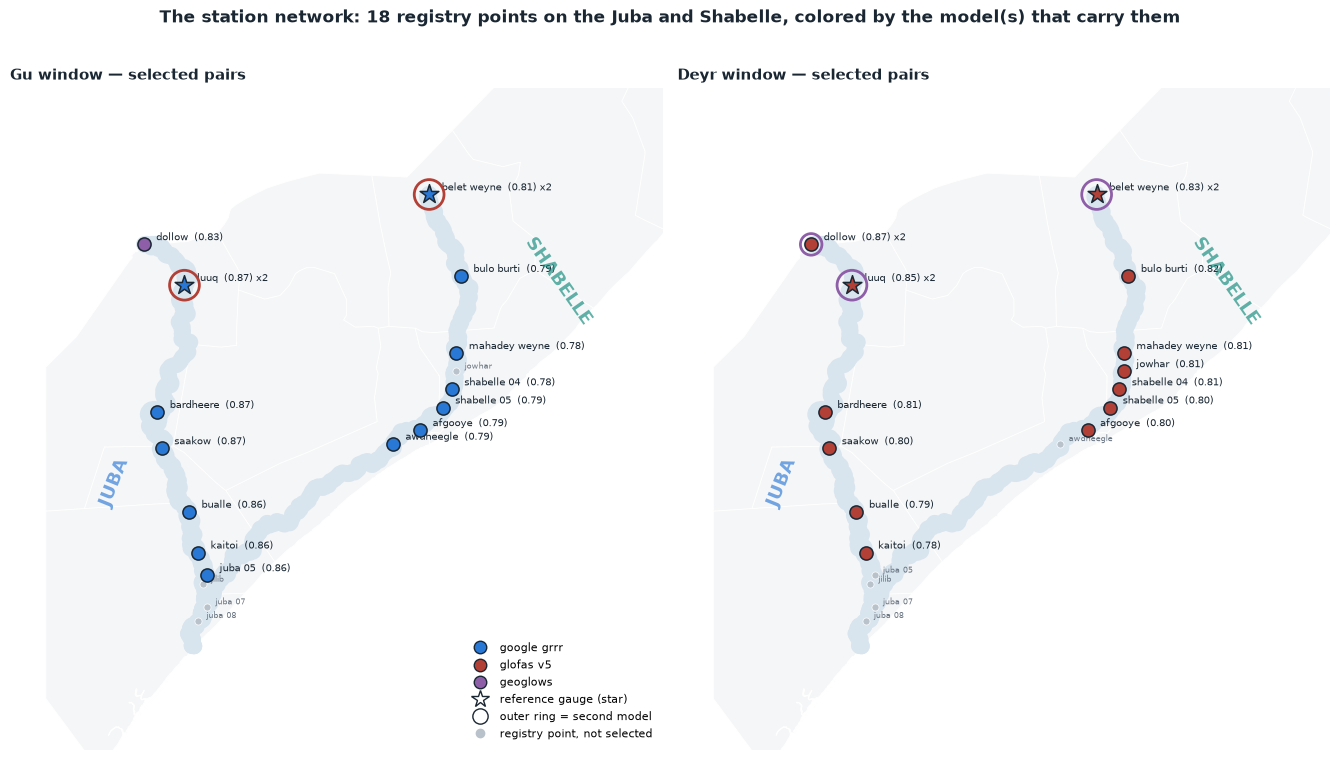

In [4]:
import os
import tempfile

import geopandas as gpd

adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 8.2))
for ax, season in zip(axes, ["gu", "deyr"]):
    adm1.plot(ax=ax, color="#F5F6F7", edgecolor="white", linewidth=0.6)
    bufs.plot(ax=ax, color="#D8E4EE")
    chosen = sel[sel.season == season]
    by_stn = {stn: g for stn, g in chosen.groupby("station")}
    for key, st in STATIONS.items():
        if key in by_stn:
            g = by_stn[key].sort_values("best_rho", ascending=False)
            is_ref = key in ("belet_weyne", "luuq")
            # primary model = filled marker; a second model = an outer ring
            ax.scatter(st.lon, st.lat, s=200 if is_ref else 90,
                       marker="*" if is_ref else "o",
                       color=SOURCE_COLORS[g.source.iloc[0]], edgecolors=INK,
                       linewidths=1.1, zorder=6 if is_ref else 5)
            if len(g) > 1:
                ax.scatter(st.lon, st.lat, s=460 if is_ref else 240,
                           marker="o", facecolors="none",
                           edgecolors=SOURCE_COLORS[g.source.iloc[1]],
                           linewidths=2.0, zorder=5)
            label = f"{key.replace('_', ' ')}  ({g.best_rho.iloc[0]:.2f})"
            if len(g) > 1:
                label += " x2"
            ax.annotate(label, (st.lon, st.lat), textcoords="offset points",
                        xytext=(9, 3), fontsize=7, color=INK)
        else:
            ax.scatter(st.lon, st.lat, s=26, color="#B9C2CA",
                       edgecolors="white", linewidths=0.5, zorder=4)
            ax.annotate(key.replace("_", " "), (st.lon, st.lat),
                        textcoords="offset points", xytext=(6, 2),
                        fontsize=6, color=FAINT)
    ax.text(41.55, 1.30, "JUBA", fontsize=13, fontweight="bold",
            color=C_JUBA, alpha=0.65, rotation=68)
    ax.text(46.25, 3.30, "SHABELLE", fontsize=13, fontweight="bold",
            color=C_SHAB, alpha=0.65, rotation=-55)
    ax.set_title(f"{season.capitalize()} window — selected pairs", loc="left", fontsize=11)
    ax.set_xlim(40.6, 47.8)
    ax.set_ylim(-1.4, 5.9)
    ax.set_axis_off()
handles = ([plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="",
                       markersize=9, markeredgecolor=INK, label=s.replace("_", " "))
            for s in ["google_grrr", "glofas_v5", "geoglows"]]
           + [plt.Line2D([], [], color=INK, marker="*", ls="", markersize=13,
                         markerfacecolor="white", label="reference gauge (star)"),
              plt.Line2D([], [], color=INK, marker="o", ls="", markersize=11,
                         markerfacecolor="none", label="outer ring = second model"),
              plt.Line2D([], [], color="#B9C2CA", marker="o", ls="", markersize=6,
                         label="registry point, not selected")])
axes[0].legend(handles=handles, fontsize=8, loc="lower right")
fig.suptitle("The station network: 18 registry points on the Juba and Shabelle, "
             "colored by the model(s) that carry them",
             fontweight="bold", color=INK, fontsize=12.5, y=0.98)
plt.tight_layout()
save_fig(fig, "map_stations")


In [5]:
# per-station selection detail -> pages/trigger/selection_detail.json
detail = {}
for (river, season), grp in corr[corr.benchmark == "swalim"].groupby(["river", "season"]):
    chosen = sel[(sel.river == river) & (sel.season == season)]
    keys = set(zip(chosen.station, chosen.source))
    rows = []
    for stn, g in grp.groupby("station"):
        row = {"station": stn}
        for src in SOURCES:
            m = g[g.source == src]
            row[src] = ({"rho": round(float(m.best_rho.iloc[0]), 3),
                         "lag": int(m.best_lag.iloc[0])} if len(m) else None)
        row["selected"] = [s for s in SOURCES if (stn, s) in keys]
        rows.append(row)
    order = {s: i for i, s in enumerate(dict.fromkeys(chosen.station))}
    rows.sort(key=lambda r: (order.get(r["station"], 99), r["station"]))
    detail[f"{river}_{season}"] = rows
(FIGS.parent / "selection_detail.json").write_text(json.dumps(detail, separators=(",", ":")))
print("wrote pages/trigger/selection_detail.json")


wrote pages/trigger/selection_detail.json


## B. Per-pair thresholds (seasonal Weibull, each model's own climatology)

Each selected (station, model) pair gets thresholds at RP 3-6 from Weibull
plotting positions on its own seasonal maxima 1999-2023 — every pair equally
likely to exceed by construction, magnitude bias between models cancelled.


In [6]:
daily, th_rows = {}, []
for _, r in sel.iterrows():
    s = dd[(dd.file_source == r.source) & (dd.station == r.station)].set_index("date")["discharge"]
    s = s[s.index.month.isin(SEASONS[r.season])]
    s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
    daily[(r.river, r.season, r.station, r.source)] = s
    am = s.groupby(s.index.year).max().dropna()
    row = {"river": r.river, "season": r.season, "station": r.station, "source": r.source}
    for rp in RP_LEVELS:
        row[f"rp{rp}"] = weibull_threshold(am.values, rp)
    th_rows.append(row)
th = pd.DataFrame(th_rows)
th.round(1)


,river,season,station,source,rp3,rp4,rp5,rp6
0,juba,deyr,dollow,glofas_v5,563.6,600.9,659.1,683.0
1,juba,deyr,luuq,glofas_v5,836.9,972.9,1070.6,1081.2
2,juba,deyr,dollow,geoglows,3729.0,4044.1,4308.6,4408.1
3,juba,deyr,luuq,geoglows,3703.1,4135.7,4278.5,4371.0
4,juba,deyr,bardheere,glofas_v5,869.3,965.9,1032.8,1054.3
5,juba,deyr,saakow,glofas_v5,846.3,943.4,1004.9,1033.5
6,juba,deyr,bualle,glofas_v5,774.2,870.7,916.7,931.5
7,juba,deyr,kaitoi,glofas_v5,722.2,823.7,853.2,884.7
8,juba,gu,bardheere,google_grrr,292.2,345.9,377.0,436.1
9,juba,gu,saakow,google_grrr,283.8,335.8,386.6,435.3


## C. Action trigger: per-window grids and the basin-level search

Per river x season, a season-year **activates** when on >= 1 day of the
season >= N of the 8 pairs simultaneously exceed their RP threshold (the
notebook-08 rule, on pairs). Basin-level search as agreed 2026-08-25:
basin activation count 4-6 in 25 years (nominal ~1-in-5, final adjustment
with the working group); maximize severe (1-in-5) coverage; minimize
activations outside the moderate (1-in-3) set; among ties prefer a consensus
fraction near 0.75, then the lower per-pair RP.


In [7]:
def pairs_of(river, season):
    g = sel[(sel.river == river) & (sel.season == season)]
    return list(zip(g.station, g.source))

acts = {}
for (river, season), grp in sel.groupby(["river", "season"]):
    pairs = pairs_of(river, season)
    for rp in RP_LEVELS:
        cols = []
        for stn, src in pairs:
            t = th[(th.river == river) & (th.season == season)
                   & (th.station == stn) & (th.source == src)][f"rp{rp}"].iloc[0]
            cols.append((daily[(river, season, stn, src)] >= t).rename(f"{stn}|{src}"))
        mat = pd.concat(cols, axis=1).fillna(False)
        mx = mat.sum(axis=1).groupby(mat.index.year).max()
        for n in range(2, TOP_N + 1):
            acts[(river, season, rp, n)] = frozenset(mx[mx >= n].index)

def tie_key(rp_g, n_g, rp_d, n_d):
    frac_pen = abs(n_g / TOP_N - 0.75) + abs(n_d / TOP_N - 0.75)
    return (frac_pen, rp_g + rp_d)

grid_rows = []
for river in ["juba", "shabelle"]:
    sev, mod = basin_bench(river, "flood_5yr"), basin_bench(river, "flood_3yr")
    for (rp_g, n_g), (rp_d, n_d) in itertools.product(
            itertools.product(RP_LEVELS, range(2, TOP_N + 1)), repeat=2):
        a = acts[(river, "gu", rp_g, n_g)] | acts[(river, "deyr", rp_d, n_d)]
        grid_rows.append({
            "river": river, "gu_rp": rp_g, "gu_n": n_g, "deyr_rp": rp_d, "deyr_n": n_d,
            "n_act": len(a), "basin_rp": (N_YEARS + 1) / len(a) if a else np.inf,
            "pod_severe": len(a & sev) / len(sev),
            "n_false": len(a - mod), "years": tuple(sorted(a)),
            "tie": tie_key(rp_g, n_g, rp_d, n_d),
        })
grid = pd.DataFrame(grid_rows)

adopted = {}
for river in ["juba", "shabelle"]:
    feas = grid[(grid.river == river) & grid.n_act.between(4, 6)]
    pick = feas.sort_values(["pod_severe", "n_false", "tie"],
                            ascending=[False, True, True]).iloc[0]
    adopted[river] = pick
    print(f"{river}: Gu RP{pick.gu_rp} >={pick.gu_n}/8 | Deyr RP{pick.deyr_rp} >={pick.deyr_n}/8"
          f" -> {pick.n_act} activations (RP {pick.basin_rp:.1f}),"
          f" severe coverage {pick.pod_severe:.2f}, {pick.n_false} outside 1-in-3 set")
    print(f"   activation years: {list(pick.years)}")

union = set(adopted['juba'].years) | set(adopted['shabelle'].years)
overall_rp = (N_YEARS + 1) / len(union)
print(f"\nOVERALL (either basin): {len(union)} of {N_YEARS} years -> RP {overall_rp:.1f}"
      f" (target >= 3.0): {sorted(union)}")


juba: Gu RP6 >=6/8 | Deyr RP4 >=5/8 -> 6 activations (RP 4.3), severe coverage 0.62, 0 outside 1-in-3 set
   activation years: [2006, 2013, 2016, 2018, 2020, 2023]
shabelle: Gu RP5 >=8/8 | Deyr RP5 >=6/8 -> 6 activations (RP 4.3), severe coverage 0.71, 0 outside 1-in-3 set
   activation years: [2006, 2014, 2018, 2019, 2020, 2023]

OVERALL (either basin): 8 of 25 years -> RP 3.2 (target >= 3.0): [2006, 2013, 2014, 2016, 2018, 2019, 2020, 2023]


In [8]:
def window_label(river, season):
    g = sel[(sel.river == river) & (sel.season == season)]
    counts = g.source.value_counts()
    return " + ".join(f"{SRC_LABEL[s]} x{n}" if n > 1 else SRC_LABEL[s]
                      for s, n in counts.items())

CONFIG = {}
for river, pick in adopted.items():
    for season, rp, n in [("gu", pick.gu_rp, pick.gu_n), ("deyr", pick.deyr_rp, pick.deyr_n)]:
        g = sel[(sel.river == river) & (sel.season == season)]
        CONFIG[(river, season)] = {
            "pairs": list(zip(g.station, g.source)),
            "stations": list(dict.fromkeys(g.station)),
            "label": window_label(river, season),
            "rp": int(rp), "n_req": int(n),
            "years": sorted(acts[(river, season, rp, n)]),
        }
cfg_rows = []
for (river, season), c in CONFIG.items():
    for stn, src in c["pairs"]:
        r = sel[(sel.river == river) & (sel.season == season)
                & (sel.station == stn) & (sel.source == src)].iloc[0]
        cfg_rows.append({
            "river": river, "season": season, "station": stn, "source": src,
            "best_rho": r.best_rho, "best_lag": int(r.best_lag),
            "rp_threshold_years": c["rp"],
            "threshold_m3s": round(th[(th.river == river) & (th.season == season)
                                      & (th.station == stn) & (th.source == src)][f"rp{c['rp']}"].iloc[0], 1),
            "n_pairs_required": c["n_req"], "n_pairs_total": len(c["pairs"]),
            "max_leadtime_days": ACTION_MAX_LEAD,
        })
cfg_df = pd.DataFrame(cfg_rows)
leg_tab = pd.DataFrame([{
    "river": r, "season": s, "models": c["label"],
    "config": f"RP{c['rp']} >={c['n_req']}/8 pairs",
    "activation_years": c["years"],
    "leg_rp": round((N_YEARS + 1) / max(len(c["years"]), 1), 1),
} for (r, s), c in CONFIG.items()])
leg_tab


,river,season,models,config,activation_years,leg_rp
0,juba,gu,Google GRRR x6 + GloFAS v5 + GEOGloWS,RP6 >=6/8 pairs,"[2013, 2016, 2018, 2020]",6.5
1,juba,deyr,GloFAS v5 x6 + GEOGloWS x2,RP4 >=5/8 pairs,"[2006, 2023]",13.0
2,shabelle,gu,Google GRRR x7 + GloFAS v5,RP5 >=8/8 pairs,"[2018, 2020]",13.0
3,shabelle,deyr,GloFAS v5 x7 + GEOGloWS,RP5 >=6/8 pairs,"[2006, 2014, 2019, 2023]",6.5


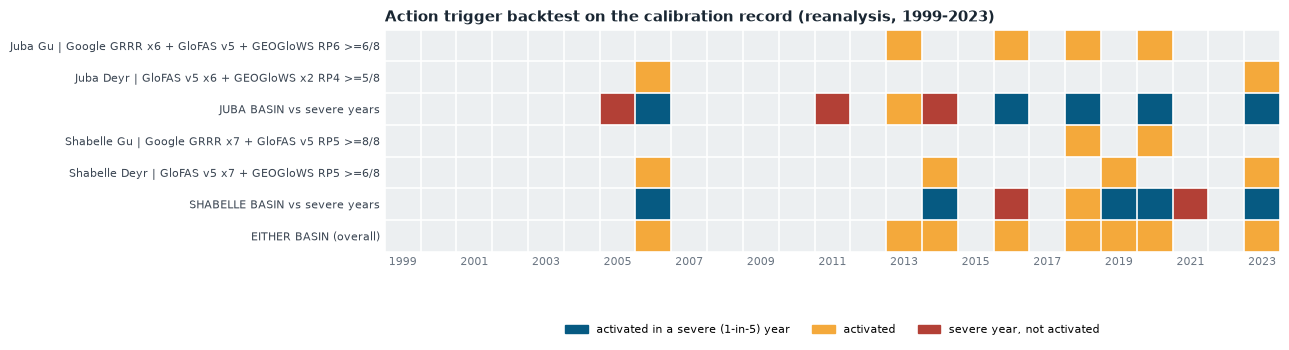

In [9]:
years = list(range(YEARS[0], YEARS[1] + 1))
rows_m, labels = [], []
for river in ["juba", "shabelle"]:
    sev = basin_bench(river, "flood_5yr")
    for season in ["gu", "deyr"]:
        c = CONFIG[(river, season)]
        a = set(c["years"])
        rows_m.append([2 if y in a else 0 for y in years])
        labels.append(f"{river.capitalize()} {season.capitalize()} | {c['label']} "
                      f"RP{c['rp']} >={c['n_req']}/8")
    a = set(adopted[river].years)
    rows_m.append([3 if (y in a and y in sev) else (2 if y in a else (1 if y in sev else 0))
                   for y in years])
    labels.append(f"{river.upper()} BASIN vs severe years")
rows_m.append([2 if y in union else 0 for y in years])
labels.append("EITHER BASIN (overall)")

cmap = mcolors.ListedColormap(["#ECEFF1", "#B34036", "#F4A93B", "#065A82"])
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.imshow(rows_m, cmap=cmap, vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(0, len(years), 2)); ax.set_xticklabels(years[::2], fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xticks([x - 0.5 for x in range(len(years) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(labels) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="both", length=0)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.legend(handles=[
    mpatches.Patch(color="#065A82", label="activated in a severe (1-in-5) year"),
    mpatches.Patch(color="#F4A93B", label="activated"),
    mpatches.Patch(color="#B34036", label="severe year, not activated"),
], loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3, fontsize=8)
ax.set_title("Action trigger backtest on the calibration record (reanalysis, 1999-2023)",
             fontsize=11)
plt.tight_layout()
save_fig(fig, "c_backtest_strip")


## D. Return-period bookkeeping (methods/return-periods.md)


In [10]:
rp_rows = []
for (river, season), c in CONFIG.items():
    rp_rows.append({"level": "individual", "trigger": f"{river} {season} action",
                    "n_act": len(c["years"]), "rp_yr": round((N_YEARS + 1) / max(len(c["years"]), 1), 1)})
for river, pick in adopted.items():
    rp_rows.append({"level": "basin", "trigger": f"{river} action (Gu or Deyr)",
                    "n_act": pick.n_act, "rp_yr": round(pick.basin_rp, 1)})
rp_rows.append({"level": "overall", "trigger": "action, either basin",
                "n_act": len(union), "rp_yr": round(overall_rp, 1)})
rp_tab = pd.DataFrame(rp_rows)
assert rp_tab[rp_tab.level == "overall"].rp_yr.iloc[0] <= rp_tab[rp_tab.level == "basin"].rp_yr.min()
rp_tab


,level,trigger,n_act,rp_yr
0,individual,juba gu action,4,6.5
1,individual,juba deyr action,2,13.0
2,individual,shabelle gu action,2,13.0
3,individual,shabelle deyr action,4,6.5
4,basin,juba action (Gu or Deyr),6,4.3
5,basin,shabelle action (Gu or Deyr),6,4.3
6,overall,"action, either basin",8,3.2


## E. Reforecast backtest of the action legs (leads <= 6 days)

What the trigger would have seen operationally. Per pair and valid day, the
most alarming <= 6-day signal (max over issue dates — the NGA convention;
with mixed providers in one window, same-issuance consensus is no longer
meaningful since providers issue on different schedules — a monitoring day
combines each provider's latest forecast):

- **Google GRRR pairs**: own reforecast, 2016-2023 (deterministic).
- **GloFAS v5 pairs**: the v4 reforecast (11-member ensemble median = the
  >= 50%-of-members rule), 2003-2023, thresholds refit on v4's own
  reanalysis climatology.
- **GEOGloWS pairs**: no reforecast exists — the retrospective stands in at
  lead 0 (the agreed reanalysis-as-stand-in convention). Flagged: these
  votes carry hindsight, so windows that include GEOGloWS pairs overstate
  operational skill by up to those votes' weight.


In [11]:
rf_grrr = load("reforecast_google_grrr")
rf_gf = load("reforecast_glofas_v4")
for df in (rf_grrr, rf_gf):
    df["valid_time"] = pd.to_datetime(df["valid_time"])
    df["issued_time"] = pd.to_datetime(df["issued_time"])

gf_a = (rf_gf[rf_gf.leadtime_days <= ACTION_MAX_LEAD]
        .groupby(["station", "issued_time", "valid_time"])["discharge"].median()
        .rename("q").reset_index())
gr_a = (rf_grrr[(rf_grrr.leadtime_days >= 1) & (rf_grrr.leadtime_days <= ACTION_MAX_LEAD)]
        .groupby(["station", "issued_time", "valid_time"])["discharge"].max()
        .rename("q").reset_index())

dd_gf4 = load("discharge_daily_glofas_v4")
dd_gf4["date"] = pd.to_datetime(dd_gf4["date"])

def v4_threshold(river, season, stn, rp):
    s = dd_gf4[dd_gf4.station == stn].set_index("date")["discharge"]
    s = s[s.index.month.isin(SEASONS[season])]
    s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
    am = s.groupby(s.index.year).max().dropna()
    return weibull_threshold(am.values, rp) if len(am) else np.nan

RF_WINDOW = {"google_grrr": (2016, 2023), "glofas_v5": (2003, 2023), "geoglows": (1999, 2023)}

def pair_signal(river, season, stn, src, rp):
    """(valid_day -> bool over, valid_day -> earliest alerting issue) for one pair."""
    months = SEASONS[season]
    if src == "google_grrr":
        d = gr_a[gr_a.station == stn]
        t = cfg_df[(cfg_df.river == river) & (cfg_df.season == season)
                   & (cfg_df.station == stn) & (cfg_df.source == src)].threshold_m3s.iloc[0]
    elif src == "glofas_v5":
        d = gf_a[gf_a.station == stn]
        t = v4_threshold(river, season, stn, rp)
    else:  # geoglows: retrospective stand-in at lead 0
        s = daily[(river, season, stn, src)]
        t = cfg_df[(cfg_df.river == river) & (cfg_df.season == season)
                   & (cfg_df.station == stn) & (cfg_df.source == src)].threshold_m3s.iloc[0]
        over = s[s >= t]
        return pd.Series(True, index=over.index), pd.Series(over.index, index=over.index)
    d = d[d.valid_time.dt.month.isin(months) & (d.q >= t)]
    if not len(d):
        return pd.Series(dtype=bool), pd.Series(dtype="datetime64[ns]")
    first_issue = d.groupby("valid_time").issued_time.min()
    return pd.Series(True, index=first_issue.index), first_issue

rf_rows, rf_backtest = [], {}
for (river, season), c in CONFIG.items():
    months = SEASONS[season]
    over_cols, issue_cols, missing = [], {}, 0
    for stn, src in c["pairs"]:
        over, first_issue = pair_signal(river, season, stn, src, c["rp"])
        if not len(over):
            missing += 1
            continue
        over_cols.append(over.rename(f"{stn}|{src}"))
        issue_cols[f"{stn}|{src}"] = first_issue
    mat = pd.concat(over_cols, axis=1).fillna(False)
    counts = mat.sum(axis=1)
    act_days = counts[counts >= c["n_req"]]
    # per activation year: alert date = n_req-th earliest first-issue on the
    # first qualifying valid day
    first_alert = {}
    for v in act_days.index:
        iss = sorted(issue_cols[col][v] for col in mat.columns if mat.loc[v, col]
                     and v in issue_cols[col].index)
        alert = iss[c["n_req"] - 1]
        y = v.year
        if y not in first_alert or alert < first_alert[y]:
            first_alert[y] = alert
    y0 = max(min(RF_WINDOW[s] for _, s in c["pairs"])[0],
             min(RF_WINDOW[src][0] for _, src in c["pairs"]))
    # evaluation window = the tightest archive among the window's REAL forecast
    # products (geoglows stand-in spans everything, so exclude it here)
    real = [src for _, src in c["pairs"] if src != "geoglows"]
    y0 = max(RF_WINDOW[s][0] for s in real) if real else 1999
    act_years = sorted(y for y in set(d.year for d in act_days.index) if y >= y0)
    ra_years = [y for y in c["years"] if y >= y0]
    n_standin = sum(1 for _, s in c["pairs"] if s == "geoglows")
    rf_backtest[(river, season)] = {"act_years": act_years, "first_alert": first_alert,
                                    "y0": y0}
    rf_rows.append({
        "river": river, "season": season, "models": c["label"],
    "rf_window": f"{y0}-2023", "standin_pairs": n_standin,
        "reforecast_activations": act_years,
        "reanalysis_activations_same_window": ra_years,
        "agree": sorted(set(act_years) & set(ra_years)),
        "rf_only": sorted(set(act_years) - set(ra_years)),
        "ra_only": sorted(set(ra_years) - set(act_years)),
    })
rf_tab = pd.DataFrame(rf_rows)
rf_tab


/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_28543/4292902927.py:59: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  mat = pd.concat(over_cols, axis=1).fillna(False)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_28543/4292902927.py:59: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  mat = pd.concat(over_cols, axis=1).fillna(False)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_28543/4292902927.py:59: Pandas4Warning: Sorting by default when concatenating all

,river,season,models,rf_window,standin_pairs,reforecast_activations,reanalysis_activations_same_window,agree,rf_only,ra_only
0,juba,gu,Google GRRR x6 + GloFAS v5 + GEOGloWS,2016-2023,1,"[2016, 2018, 2020]","[2016, 2018, 2020]","[2016, 2018, 2020]",[],[]
1,juba,deyr,GloFAS v5 x6 + GEOGloWS x2,2003-2023,2,"[2005, 2014, 2015, 2017, 2023]","[2006, 2023]",[2023],"[2005, 2014, 2015, 2017]",[2006]
2,shabelle,gu,Google GRRR x7 + GloFAS v5,2016-2023,0,[2016],"[2018, 2020]",[],[2016],"[2018, 2020]"
3,shabelle,deyr,GloFAS v5 x7 + GEOGloWS,2003-2023,1,"[2013, 2019]","[2006, 2014, 2019, 2023]",[2019],[2013],"[2006, 2014, 2023]"


### Per-event operational anticipation

Days between the alert date (the n-th pair's earliest alerting forecast on
the first consensus day; GEOGloWS stand-in votes count as same-day
information) and the season's first SWALIM Moderate crossing at the
reference gauge. Positive = the trigger preceded the observed crossing.


In [12]:
lead_rows = []
for (river, season), c in CONFIG.items():
    gauge = REF_GAUGE[river]
    mod_level = sw_th.loc[gauge, "moderate_flood_risk"]
    s = lv[lv.station == gauge].set_index("date")["level_m"]
    s = s[s.index.month.isin(SEASONS[season])]
    bt = rf_backtest[(river, season)]
    for y, alert in sorted(bt["first_alert"].items()):
        if y < bt["y0"]:
            continue
        cross = s[(s.index.year == y) & (s >= mod_level)]
        onset = cross.index.min() if len(cross) else pd.NaT
        lead_rows.append({
            "river": river, "season": season, "year": int(y),
            "first_alert": alert.date(),
            "swalim_moderate_onset": onset.date() if pd.notna(onset) else None,
            "anticipation_days": (onset - alert).days if pd.notna(onset) else np.nan,
        })
lead_tab = pd.DataFrame(lead_rows).sort_values(["river", "season", "year"])
lead_tab


,river,season,year,first_alert,swalim_moderate_onset,anticipation_days
3,juba,deyr,2005,2005-10-23,None,NaN
4,juba,deyr,2014,2014-10-23,2014-10-14,-9.0
5,juba,deyr,2015,2015-10-23,None,NaN
6,juba,deyr,2017,2017-10-21,None,NaN
7,juba,deyr,2023,2023-10-21,2023-10-05,-16.0
0,juba,gu,2016,2016-05-05,2016-04-30,-5.0
1,juba,gu,2018,2018-04-18,2018-04-18,0.0
2,juba,gu,2020,2020-04-28,2020-05-12,14.0
9,shabelle,deyr,2013,2013-10-07,2013-10-28,21.0
10,shabelle,deyr,2019,2019-10-02,2019-10-13,11.0


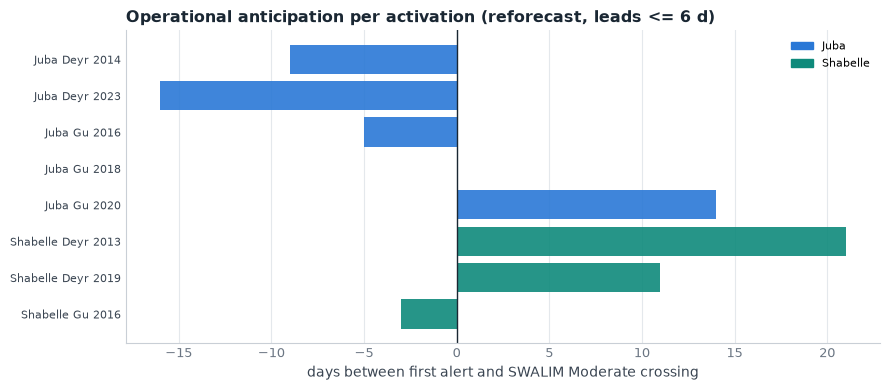

In [13]:
sub = lead_tab.dropna(subset=["anticipation_days"])
fig, ax = plt.subplots(figsize=(9, 4))
colors = {"juba": C_JUBA, "shabelle": C_SHAB}
for i, (_, r) in enumerate(sub.iterrows()):
    ax.barh(i, r.anticipation_days, color=colors[r.river], alpha=0.9)
ax.set_yticks(range(len(sub)))
ax.set_yticklabels([f"{r.river.capitalize()} {r.season.capitalize()} {r.year}"
                    for _, r in sub.iterrows()], fontsize=8)
ax.axvline(0, color=INK, lw=1)
ax.invert_yaxis()
ax.set_xlabel("days between first alert and SWALIM Moderate crossing")
ax.set_title("Operational anticipation per activation (reforecast, leads <= 6 d)")
ax.legend(handles=[mpatches.Patch(color=C_JUBA, label="Juba"),
                   mpatches.Patch(color=C_SHAB, label="Shabelle")], fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "e_anticipation")


## F. Forecast skill against each model's own reanalysis

The assume-bias-for-all-sources rule, quantified: per model and lead time,
how well does the forecast reproduce the model's own reanalysis /
retrospective — rank correlation (does it track itself?) and median
forecast/reanalysis ratio (is it biased against its own climatology?).
Computed per station on flood-season days, median across the 18 stations.

Records differ enormously and that is part of the message: GloFAS v4 has 21
years of reforecast, GRRR 8, **GEOGloWS only ~2 (2024-07 onward)** — and no
GloFAS **v5** reforecast exists at all, so the operational v5 forecast's own
consistency is untestable (the single most important gap).


median_ratio                       rho_vs_own                      
model     geoglows glofas_v4 google_grrr   geoglows glofas_v4 google_grrr
lead                                                                     
1             0.91      1.00        1.00       0.81      1.00        0.99
2             0.90      1.00        1.00       0.82      1.00        0.99
3             0.89      1.00        1.00       0.82      1.00        0.99
4             0.89      1.00        1.00       0.83      1.00        0.99
5             0.87      1.00        1.00       0.82      1.00        0.99
6             0.87      0.99        1.00       0.82      1.00        0.99
7             0.85      0.99        1.01       0.82      0.99        0.99
8              NaN      0.98         NaN        NaN      0.99         NaN
9              NaN      0.96         NaN        NaN      0.99         NaN
10             NaN      0.94         NaN        NaN      0.98         NaN
11             NaN      0.92         NaN        NaN      0.98         NaN
12             NaN      0.90         NaN        NaN      0.97         NaN

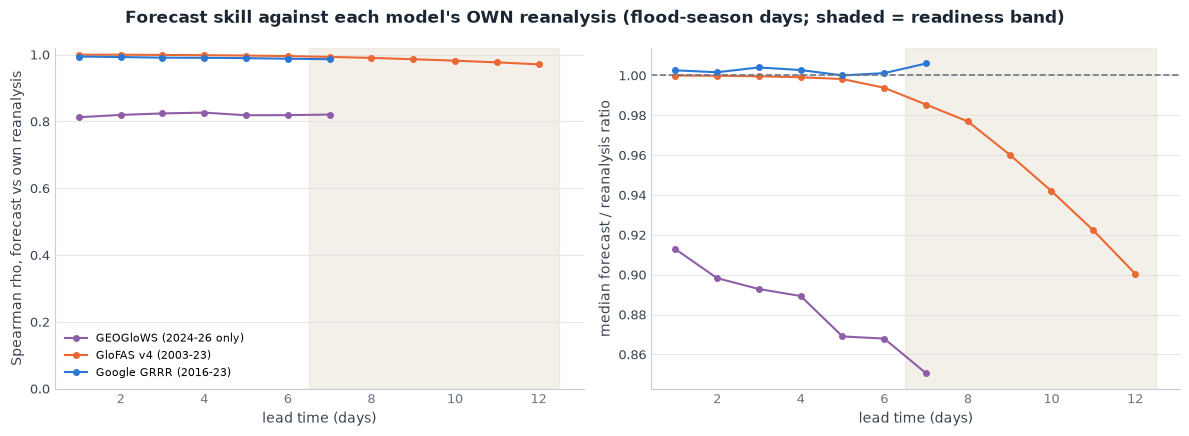

In [14]:
rf812 = load("reforecast_glofas_v4_lead8_12")
rf812["valid_time"] = pd.to_datetime(rf812["valid_time"])
rf_gg = load("reforecast_geoglows")
rf_gg["valid_time"] = pd.to_datetime(rf_gg["valid_time"])
if getattr(rf_gg.valid_time.dt, "tz", None) is not None:
    rf_gg["valid_time"] = rf_gg.valid_time.dt.tz_localize(None)

SEASON_MONTHS_ALL = SEASONS["gu"] + SEASONS["deyr"]

def own_skill(fc, ra, leads, label):
    med = (fc[fc.leadtime_days.isin(leads)]
           .groupby(["station", "leadtime_days", "valid_time"])["discharge"].median()
           .rename("fc").reset_index())
    med = med[med.valid_time.dt.month.isin(SEASON_MONTHS_ALL)]
    ra2 = ra.rename(columns={"date": "valid_time", "discharge": "ra"})[
        ["station", "valid_time", "ra"]]
    j = med.merge(ra2, on=["station", "valid_time"])
    rows = []
    for lead, g in j.groupby("leadtime_days"):
        rhos, ratios = [], []
        for stn, gs in g.groupby("station"):
            if len(gs) < 60:
                continue
            rhos.append(gs.fc.rank().corr(gs.ra.rank()))
            ratios.append((gs.fc / gs.ra.replace(0, np.nan)).median())
        rows.append({"model": label, "lead": int(lead),
                     "rho_vs_own": float(np.median(rhos)),
                     "median_ratio": float(np.median(ratios)),
                     "n_stations": len(rhos),
                     "n_days": int(g.valid_time.nunique())})
    return rows

skill_rows = []
skill_rows += own_skill(pd.concat([rf_gf, rf812]),
                        dd_gf4, range(1, 13), "glofas_v4")
skill_rows += own_skill(rf_grrr, dd[dd.file_source == "google_grrr"].rename(
    columns={"file_source": "src"}), range(1, 8), "google_grrr")
skill_rows += own_skill(rf_gg, dd[dd.file_source == "geoglows"].rename(
    columns={"file_source": "src"}), range(1, 15), "geoglows")
own = pd.DataFrame(skill_rows)

SK_COLOR = {"glofas_v4": C_GLOFAS4, "google_grrr": C_GOOGLE, "geoglows": C_GEOGLOWS}
SK_LABEL = {"glofas_v4": "GloFAS v4 (2003-23)", "google_grrr": "Google GRRR (2016-23)",
            "geoglows": "GEOGloWS (2024-26 only)"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for model, g in own.groupby("model"):
    g = g.sort_values("lead")
    axes[0].plot(g.lead, g.rho_vs_own, marker="o", ms=4, color=SK_COLOR[model],
                 label=SK_LABEL[model])
    axes[1].plot(g.lead, g.median_ratio, marker="o", ms=4, color=SK_COLOR[model])
axes[0].set_ylabel("Spearman rho, forecast vs own reanalysis")
axes[0].set_ylim(0, 1.02)
axes[1].axhline(1.0, color=FAINT, lw=1.2, ls="--")
axes[1].set_ylabel("median forecast / reanalysis ratio")
for ax in axes:
    ax.set_xlabel("lead time (days)")
    ax.axvspan(6.5, 12.5, color=C_BAND, alpha=0.5)
    style_ax(ax, grid="y")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Forecast skill against each model's OWN reanalysis (flood-season days; "
             "shaded = readiness band)", fontweight="bold", color=INK, fontsize=12)
plt.tight_layout()
save_fig(fig, "f_own_skill")
own.pivot_table(index="lead", columns="model", values=["rho_vs_own", "median_ratio"]).round(2)


## G. Readiness trigger (GloFAS, leads 7-12 days)

GloFAS-only (the only validatable archive past 7 days). v4 reforecast leads
7 (leads-1-7 archive) + 8-12 (`reforecast_glofas_v4_lead8_12`), ensemble
median per (station, issue, valid), best signal across the band, thresholds
on v4's own climatology, over the window's distinct stations. Target
activation RP 2.5-4.5, maximize coverage of the window's action years.


In [15]:
band = pd.concat([rf_gf[rf_gf.leadtime_days.between(*READY_LEADS)],
                  rf812[rf812.leadtime_days.between(*READY_LEADS)]], ignore_index=True)
band_sig = (band.groupby(["station", "issued_time", "valid_time"])["discharge"].median()
            .rename("q").reset_index())
print(f"readiness band: {band_sig.station.nunique()} stations, issues "
      f"{band.issued_time.min().date()} -> {band.issued_time.max().date()}")

ready_rows = []
for (river, season), c in CONFIG.items():
    months = SEASONS[season]
    action_years = set(c["years"]) & set(range(2003, 2024))
    stations = c["stations"]
    for rp in (2, 3):
        ths = {stn: v4_threshold(river, season, stn, rp) for stn in stations}
        ths = {k: v for k, v in ths.items() if not np.isnan(v)}
        d = band_sig[band_sig.station.isin(ths)
                     & band_sig.valid_time.dt.month.isin(months)].copy()
        d["over"] = d.q >= d.station.map(ths)
        n_iv = d.groupby(["issued_time", "valid_time"])["over"].sum()
        for n in range(2, len(ths) + 1):
            act = sorted(set(n_iv[n_iv >= n].reset_index().valid_time.dt.year))
            ready_rows.append({
                "river": river, "season": season, "rp": rp, "n_req": n,
                "n_stations": len(ths), "n_act": len(act),
                "rp_act": round(22 / max(len(act), 1), 1),
                "action_coverage": (len(set(act) & action_years) / len(action_years)
                                    if action_years else np.nan),
                "years": act,
            })
ready_grid = pd.DataFrame(ready_rows)

READY = {}
for (river, season), grp in ready_grid.groupby(["river", "season"]):
    feas = grp[grp.rp_act.between(2.5, 4.5)]
    if not len(feas):
        feas = grp
    pick = feas.sort_values(["action_coverage", "rp_act"], ascending=[False, False]).iloc[0]
    READY[(river, season)] = pick
ready_tab = pd.DataFrame([{
    "river": r, "season": s, "config": f"GloFAS RP{p.rp} >={p.n_req}/{p.n_stations}",
    "readiness_rp": p.rp_act,
    "action_coverage": round(p.action_coverage, 2) if p.action_coverage == p.action_coverage else None,
    "years": p.years} for (r, s), p in READY.items()])
ready_union = sorted(set().union(*[set(p.years) for p in READY.values()]))
print(f"readiness overall: {len(ready_union)} of 21 years -> RP {22 / len(ready_union):.1f}")
ready_tab


readiness band: 18 stations, issues 2003-03-27 -> 2023-11-25
readiness overall: 13 of 21 years -> RP 1.7


,river,season,config,readiness_rp,action_coverage,years
0,juba,deyr,GloFAS RP2 >=5/6,4.4,1.0,"[2005, 2006, 2015, 2017, 2023]"
1,juba,gu,GloFAS RP2 >=4/7,3.7,1.0,"[2005, 2010, 2013, 2016, 2018, 2020]"
2,shabelle,deyr,GloFAS RP2 >=5/7,3.1,0.5,"[2007, 2010, 2013, 2014, 2017, 2019, 2020]"
3,shabelle,gu,GloFAS RP3 >=2/7,3.7,1.0,"[2005, 2010, 2013, 2016, 2018, 2020]"


## H. The mechanism, assembled


In [16]:
mech_rows = []
for (river, season), c in CONFIG.items():
    p = READY[(river, season)]
    mech_rows.append({
        "window": f"{river} {season}",
        "readiness_7_12d": f"GloFAS ens-median RP{p.rp} >={p.n_req}/{p.n_stations} (RP {p.rp_act})",
        "action_<=6d": f"{c['label']}: RP{c['rp']} >={c['n_req']}/8 pairs",
        "action_leg_rp": round((N_YEARS + 1) / max(len(c["years"]), 1), 1),
        "action_years": c["years"],
    })
mech = pd.DataFrame(mech_rows)
mech


,window,readiness_7_12d,action_<=6d,action_leg_rp,action_years
0,juba gu,GloFAS ens-median RP2 >=4/7 (RP 3.7),Google GRRR x6 + GloFAS v5 + GEOGloWS: RP6 >=6...,6.5,"[2013, 2016, 2018, 2020]"
1,juba deyr,GloFAS ens-median RP2 >=5/6 (RP 4.4),GloFAS v5 x6 + GEOGloWS x2: RP4 >=5/8 pairs,13.0,"[2006, 2023]"
2,shabelle gu,GloFAS ens-median RP3 >=2/7 (RP 3.7),Google GRRR x7 + GloFAS v5: RP5 >=8/8 pairs,13.0,"[2018, 2020]"
3,shabelle deyr,GloFAS ens-median RP2 >=5/7 (RP 3.1),GloFAS v5 x7 + GEOGloWS: RP5 >=6/8 pairs,6.5,"[2006, 2014, 2019, 2023]"


## I. Seasonal peaks: model vs gauge

One point per season-year: the model's seasonal peak (divided by its own
1-in-6 threshold — rank correlation is normalisation-invariant) against the
observed seasonal peak at the reference gauge. Two views: the calibration
record and the <= 6-day reforecast record (each normalised on that product's
OWN seasonal maxima).


source           geoglows  glofas_v5  google_grrr
river    season                                  
juba     deyr       0.648      0.593        0.736
         gu         0.646      0.642        0.847
shabelle deyr       0.485      0.771        0.776
         gu         0.683      0.796        0.854

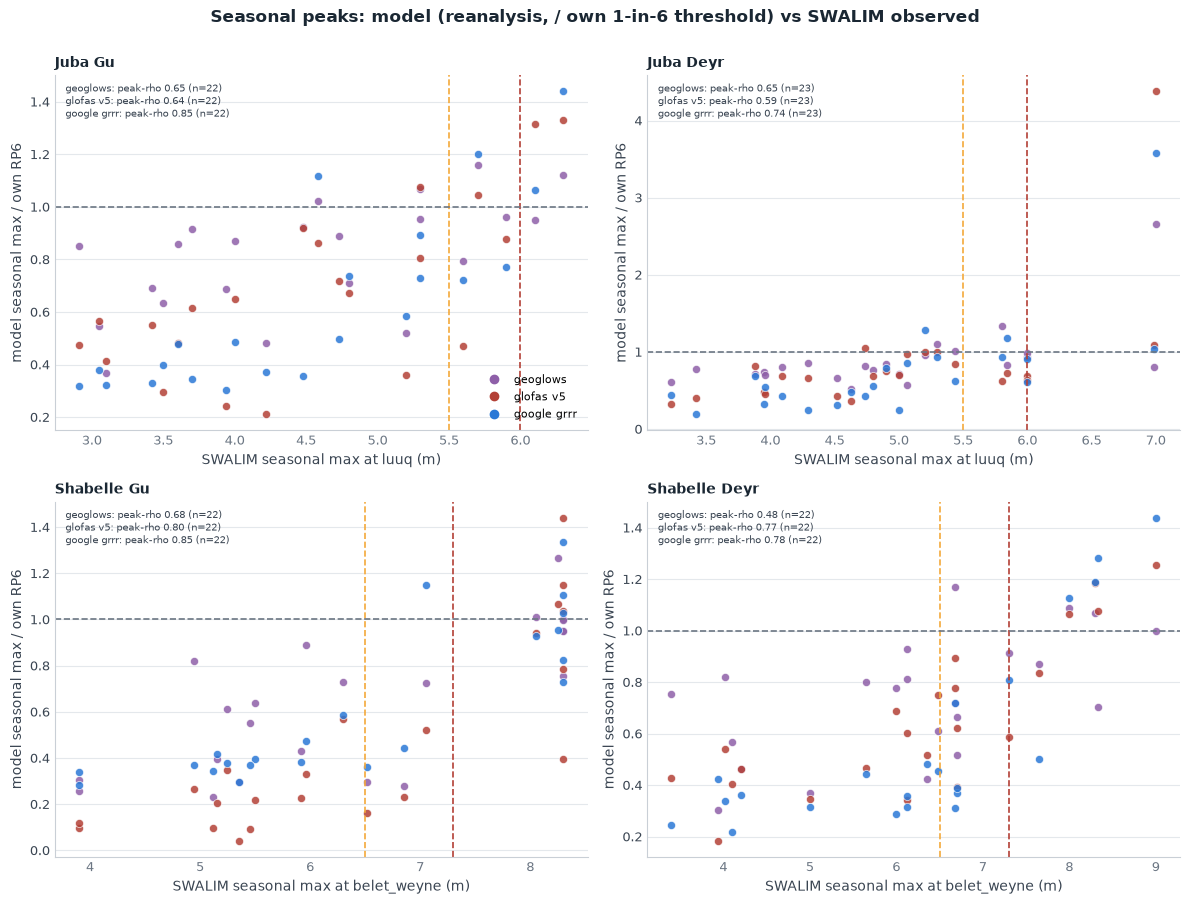

In [17]:
def swalim_peaks(river, season):
    g = REF_GAUGE[river]
    s = lv[lv.station == g].set_index("date")["level_m"]
    s = s[s.index.month.isin(SEASONS[season])]
    s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
    return s.groupby(s.index.year).max().dropna()

def spearman(x, y):
    return float(pd.Series(x).rank().corr(pd.Series(y).rank()))

def peak_panel(ax, river, season, model_peaks, title_extra=""):
    obs = swalim_peaks(river, season)
    ax.axvline(sw_th.loc[REF_GAUGE[river], "moderate_flood_risk"], color="#F4A93B",
               lw=1.2, ls="--")
    ax.axvline(sw_th.loc[REF_GAUGE[river], "high_flood_risk"], color="#B34036",
               lw=1.2, ls="--")
    ax.axhline(1.0, color=FAINT, lw=1.2, ls="--")
    labels = []
    for src, pk in model_peaks.items():
        common = obs.index.intersection(pk.index)
        if len(common) < 5:
            continue
        rho = spearman(obs.loc[common], pk.loc[common])
        ax.scatter(obs.loc[common], pk.loc[common], s=34,
                   color=SOURCE_COLORS[src], alpha=0.85,
                   edgecolors="white", linewidths=0.5)
        labels.append(f"{src.replace('_', ' ')}: peak-rho {rho:.2f} (n={len(common)})")
    ax.set_title(f"{river.capitalize()} {season.capitalize()}{title_extra}", fontsize=10)
    ax.set_xlabel(f"SWALIM seasonal max at {REF_GAUGE[river]} (m)")
    ax.set_ylabel("model seasonal max / own RP6")
    ax.text(0.02, 0.98, "\n".join(labels), transform=ax.transAxes, fontsize=7.5,
            va="top", color=BODY)
    style_ax(ax, grid="y")

peak_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (river, season) in zip(axes.ravel(), combos):
    months = SEASONS[season]
    mp = {}
    for src in SOURCES:
        s = dd[(dd.file_source == src) & (dd.station == REF_GAUGE[river])].set_index("date")["discharge"]
        s = s[s.index.month.isin(months)]
        s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
        am = s.groupby(s.index.year).max().dropna()
        t = weibull_threshold(am.values, 6)
        mp[src] = am / t
        obs = swalim_peaks(river, season)
        common = obs.index.intersection(am.index)
        peak_rows.append({"river": river, "season": season, "source": src, "record": "reanalysis",
                          "n_years": len(common),
                          "peak_rho": round(spearman(obs.loc[common], am.loc[common]), 3)})
    peak_panel(ax, river, season, mp)
handles = [plt.Line2D([], [], color=SOURCE_COLORS[s], marker="o", ls="",
                      label=s.replace("_", " ")) for s in SOURCES]
axes.ravel()[0].legend(handles=handles, fontsize=8, loc="lower right")
fig.suptitle("Seasonal peaks: model (reanalysis, / own 1-in-6 threshold) vs SWALIM observed",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()
save_fig(fig, "i_peaks_reanalysis")
pd.DataFrame(peak_rows).pivot_table(index=["river", "season"], columns="source",
                                    values="peak_rho")


source                          geoglows  glofas_v5  google_grrr
river    season record                                          
juba     deyr   reanalysis         0.648      0.593        0.736
                reforecast<=6d       NaN      0.639        0.750
         gu     reanalysis         0.646      0.642        0.847
                reforecast<=6d       NaN      0.629        0.976
shabelle deyr   reanalysis         0.485      0.771        0.776
                reforecast<=6d       NaN      0.392        0.811
         gu     reanalysis         0.683      0.796        0.854
                reforecast<=6d       NaN      0.640        0.736

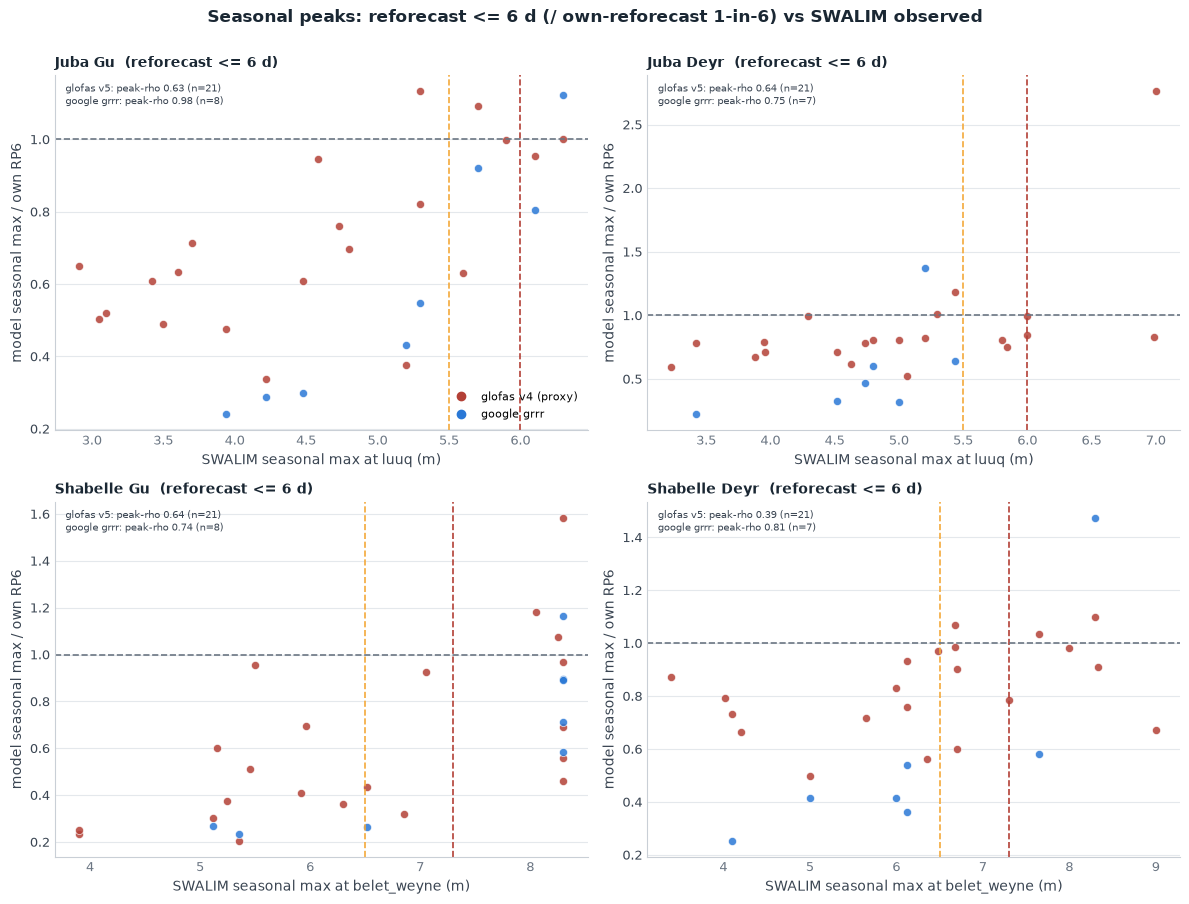

In [18]:
RF6 = {"glofas_v5": gf_a, "google_grrr": gr_a}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (river, season) in zip(axes.ravel(), combos):
    months = SEASONS[season]
    mp = {}
    for src, tab in RF6.items():
        s = tab[tab.station == REF_GAUGE[river]]
        s = s[s.valid_time.dt.month.isin(months)]
        pk = s.groupby(s.valid_time.dt.year)["q"].max().dropna()
        if len(pk) < 5:
            continue
        t = weibull_threshold(pk.values, 6)
        mp[src] = pk / t
        obs = swalim_peaks(river, season)
        common = obs.index.intersection(pk.index)
        peak_rows.append({"river": river, "season": season, "source": src, "record": "reforecast<=6d",
                          "n_years": len(common),
                          "peak_rho": round(spearman(obs.loc[common], pk.loc[common]), 3)})
    peak_panel(ax, river, season, mp, "  (reforecast <= 6 d)")
handles = [plt.Line2D([], [], color=SOURCE_COLORS["glofas_v5"], marker="o", ls="",
                      label="glofas v4 (proxy)"),
           plt.Line2D([], [], color=SOURCE_COLORS["google_grrr"], marker="o", ls="",
                      label="google grrr")]
axes.ravel()[0].legend(handles=handles, fontsize=8, loc="lower right")
fig.suptitle("Seasonal peaks: reforecast <= 6 d (/ own-reforecast 1-in-6) vs SWALIM observed",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()
save_fig(fig, "i_peaks_reforecast")
peaks_df = pd.DataFrame(peak_rows)
peaks_df.pivot_table(index=["river", "season", "record"], columns="source", values="peak_rho")


## J. Activations, impact and response, year by year

The two-historical-records rule. Per basin x season: whether EACH model's
consensus would have activated on the calibration record (the window's
distinct stations with that model's own RP6 thresholds; required count
scaled from the adopted pair requirement), the SWALIM benchmark class of the
season, IDMC flood displacement (basin from the region in the event name),
plus season-level EM-DAT impacts and CERF flood allocations.


In [19]:
import io
import re
import requests

import math

JUBA_RE = r"juba|gedo|bardhe+re|baardheere|luuq|doo?low|bu'?aale|buale|saakow|jilib|kismayo|jamaame|dujuma"
SHAB_RE = r"sh?abell?e|hiraan|hiran|belet\s?weyne|beledweyne|bulo\s?burti|jowhar|balcad|afgooye|hirshabelle|wanla\s?weyn"

def basins_of(text):
    text = str(text)
    out = []
    if re.search(JUBA_RE, text, re.I):
        out.append("J")
    if re.search(SHAB_RE, text, re.I):
        out.append("S")
    return "+".join(out)

def season_of_month(m):
    if m in (3, 4, 5, 6):
        return "gu"
    if m in (9, 10, 11, 12):
        return "deyr"
    return None

# per-model activation years per window: the window's distinct stations with
# that model's own RP6 thresholds; required count scaled from the pair rule
act_by_src = {}
for (river, season), c in CONFIG.items():
    months = SEASONS[season]
    stations = c["stations"]
    n_req_stn = max(2, math.ceil(c["n_req"] * len(stations) / 8))
    for src in SOURCES:
        cols = []
        for stn in stations:
            s = dd[(dd.file_source == src) & (dd.station == stn)].set_index("date")["discharge"]
            s = s[s.index.month.isin(months)]
            s = s[(s.index.year >= YEARS[0]) & (s.index.year <= YEARS[1])]
            am = s.groupby(s.index.year).max().dropna()
            if not len(am):
                continue
            t = weibull_threshold(am.values, 6)
            if np.isnan(t):
                continue
            cols.append((s >= t).rename(stn))
        mat = pd.concat(cols, axis=1).fillna(False)
        mx = mat.sum(axis=1).groupby(mat.index.year).max()
        act_by_src[(river, season, src)] = set(mx[mx >= n_req_stn].index)


In [20]:
# EM-DAT floods (blob snapshot via ocha-stratus)
em = stratus.emdat.load_emdat_from_blob("som")
em = em[em["Disaster Type"].str.contains("Flood", case=False, na=False)].copy()
em["season"] = em["Start Month"].apply(lambda m: season_of_month(int(m)) if pd.notna(m) else None)
em["basins"] = (em["Location"].fillna("") + " " + em["Admin Units"].fillna("").astype(str)).apply(basins_of)
em_rows = []
for (y, se), g in em.groupby(["Start Year", "season"]):
    if se is None or not (YEARS[0] <= y <= YEARS[1]):
        continue
    em_rows.append({"year": int(y), "season": se,
                    "affected": int(g["Total Affected"].fillna(0).sum()),
                    "deaths": int(g["Total Deaths"].fillna(0).sum()),
                    "basins": "+".join(sorted(set("".join(g.basins.str.replace("+", ""))))) or "?"})
emdat_t = pd.DataFrame(em_rows)

# CERF flood allocations (aa.cerf_allocation mirror, dev DB)
eng = stratus.get_engine(stage="dev")
cerf = pd.read_sql(
    """select application_code, year, emergency_type, amount_approved,
              first_project_approved_date, title, summary, humanitarian_overview
       from aa.cerf_allocation
       where country_iso3 = 'SOM' and emergency_type = 'Flood'""", eng)
cerf["month"] = pd.to_datetime(cerf.first_project_approved_date).dt.month
cerf["season"] = cerf.month.apply(season_of_month)
cerf["basins"] = (cerf.summary.fillna("") + " " + cerf.humanitarian_overview.fillna("")).apply(basins_of)
cerf_t = cerf[["application_code", "year", "season", "amount_approved", "basins"]]

# IDMC flood displacement events (HDX)
IDMC_URL = ("https://data.humdata.org/dataset/c67f8253-b5c5-4f6c-ba34-9af41331d1f2/"
            "resource/fbcfcd16-6997-4212-ad1b-a2f7355624aa/download")
idmc = pd.read_csv(io.BytesIO(requests.get(IDMC_URL, timeout=120).content), skiprows=[1])
idmc = idmc[idmc.hazard_type_name.str.contains("Flood", case=False, na=False)].copy()
idmc["region"] = idmc.event_name.str.split(" - ").str[1].str.strip()
IDMC_BASIN = {"Gedo": "juba", "Middle Juba": "juba", "Lower Juba": "juba",
              "Hiraan": "shabelle", "Hiran": "shabelle",
              "Middle Shabelle": "shabelle", "Lower Shabelle": "shabelle"}
idmc["basin"] = idmc.region.map(IDMC_BASIN).fillna("other")
idmc["season"] = pd.to_datetime(idmc.start_date).dt.month.apply(season_of_month)
idmc_t = (idmc.dropna(subset=["season"])
          .groupby(["year", "basin", "season"]).new_displacement.sum()
          .astype(int).reset_index())
stratus.upload_parquet_to_blob(
    idmc_t, "ds-aa-som-floods/processed/workflow/som_impact_idmc.parquet", stage="dev")
print("impact sources loaded:", len(emdat_t), "EM-DAT season-rows,",
      len(cerf_t), "CERF allocations,", len(idmc_t), "IDMC basin-season rows")


impact sources loaded: 25 EM-DAT season-rows, 5 CERF allocations, 32 IDMC basin-season rows


In [21]:
def season_bench_class(river, season, year):
    if year in bench_years(river, season, "flood_5yr"):
        return "severe"
    if year in bench_years(river, season, "flood_3yr"):
        return "moderate"
    return ""

table = []
for year in range(YEARS[0], YEARS[1] + 1):
    row = {"year": year, "basins": {}, "national": {}}
    for river in ("juba", "shabelle"):
        row["basins"][river] = {}
        for season in ("gu", "deyr"):
            g = idmc_t[(idmc_t.year == year) & (idmc_t.basin == river)
                       & (idmc_t.season == season)]
            row["basins"][river][season] = {
                "act": {src: bool(year in act_by_src[(river, season, src)])
                        for src in SOURCES},
                "adopted": bool(year in CONFIG[(river, season)]["years"]),
                "bench": season_bench_class(river, season, year),
                "idmc": int(g.new_displacement.sum()),
            }
    nat = {"emdat": {}, "cerf": {}}
    for se in ("gu", "deyr"):
        e = emdat_t[(emdat_t.year == year) & (emdat_t.season == se)]
        nat["emdat"][se] = ({"affected": int(e.affected.sum()), "deaths": int(e.deaths.sum()),
                             "basins": e.basins.iloc[0] if len(e) else ""}
                            if len(e) else None)
        c2 = cerf_t[(cerf_t.year == year) & (cerf_t.season == se)]
        nat["cerf"][se] = ({"usd": int(c2.amount_approved.sum()), "basins": c2.basins.iloc[0]}
                           if len(c2) else None)
    g = idmc_t[(idmc_t.year == year) & (idmc_t.basin == "other")]
    nat["idmc_other"] = int(g.new_displacement.sum())
    row["national"] = nat
    table.append(row)

meta = {"note": "activations on the calibration record; each model over the window's "
                "distinct stations with its own RP6 thresholds; required count scaled "
                "from the adopted pair rule; IDMC coverage 2010-2025",
        "windows": {f"{r}_{s}": {"label": CONFIG[(r, s)]["label"],
                                 "n_req": CONFIG[(r, s)]["n_req"]}
                    for (r, s) in CONFIG}}
(FIGS.parent / "activation_impact.json").write_text(
    json.dumps({"meta": meta, "rows": table}, separators=(",", ":")))
print("wrote pages/trigger/activation_impact.json")


wrote pages/trigger/activation_impact.json


## K. Save outputs


In [22]:
OUT = "ds-aa-som-floods/processed/workflow"
def save(df, name):
    df = df.copy()
    for col in df.columns:
        if df[col].apply(lambda v: isinstance(v, (list, tuple))).any():
            df[col] = df[col].apply(lambda v: ",".join(map(str, v)) if isinstance(v, (list, tuple)) else v)
    df.to_parquet(DATA / "workflow" / f"{name}.parquet", index=False)
    stratus.upload_parquet_to_blob(df, f"{OUT}/{name}.parquet", stage="dev")
    print(f"saved {name} ({len(df)})")

save(sel, "som_ms_selected_stations")
save(cfg_df, "som_ms_trigger_config")
save(leg_tab, "som_ms_trigger_legs")
save(rp_tab, "som_ms_return_periods")
save(rf_tab, "som_ms_reforecast_backtest")
save(lead_tab, "som_ms_anticipation")
save(ready_tab, "som_ms_readiness")
save(mech, "som_ms_mechanism_summary")
save(peaks_df, "som_ms_peak_correlations")
save(own, "som_ms_own_forecast_skill")
summary = {
    "adopted": {f"{r}_{s}": {"label": c["label"], "rp": c["rp"], "n_req": c["n_req"],
                             "years": c["years"]} for (r, s), c in CONFIG.items()},
    "basin_rp": {r: round(float(adopted[r].basin_rp), 1) for r in adopted},
    "overall_rp": round(float(overall_rp), 1),
    "overall_years": sorted(union),
}
(FIGS.parent / "summary.json").write_text(json.dumps(summary, indent=2))
print("wrote pages/trigger/summary.json")


saved som_ms_selected_stations (32)


saved som_ms_trigger_config (32)


saved som_ms_trigger_legs (4)


saved som_ms_return_periods (7)


saved som_ms_reforecast_backtest (4)


saved som_ms_anticipation (11)


saved som_ms_readiness (4)


saved som_ms_mechanism_summary (4)


saved som_ms_peak_correlations (20)


saved som_ms_own_forecast_skill (26)
wrote pages/trigger/summary.json


## Findings (step 8, v2)

**The adopted mechanism** (calibrated on reanalysis/retrospective 1999-2023,
SWALIM reference-gauge benchmark; pairs compete freely with a -3 d timing
guard and the diversity rule):

| window | action (leads <= 6 d) | leg RP | readiness (7-12 d, GloFAS v4 ens-median) | readiness RP |
|---|---|---|---|---|
| Juba Gu | Google GRRR x6 + GloFAS v5 (luuq) + GEOGloWS (dollow): >= 6/8 pairs over RP6 | 6.5 y | RP2 >= 4/7 | 3.7 y |
| Juba Deyr | GloFAS v5 x6 + GEOGloWS x2 (dollow, luuq): >= 5/8 over RP4 | 13.0 y | RP2 >= 5/6 | 4.4 y |
| Shabelle Gu | Google GRRR x7 + GloFAS v5 (belet weyne): 8/8 over RP5 | 13.0 y | RP3 >= 2/7 | 3.7 y |
| Shabelle Deyr | GloFAS v5 x7 + GEOGloWS (belet weyne): >= 6/8 over RP5 | 6.5 y | RP2 >= 5/7 | 3.1 y |

**Return periods**: each basin 6/25 years -> **1-in-4.3, equal by
construction**; union 8 years -> **overall action RP 3.2 y** (target >= 3.0).
Activation years 2006, 2013, 2014, 2016, 2018, 2019, 2020, 2023 — all
documented major floods. Severe coverage: Juba 5/8 (misses 2005, 2011,
2014), Shabelle 5/7 (misses 2016, 2021) with zero activations outside the
1-in-3 set. Readiness legs 3.1-4.4 y individually; union ~1-in-1.7.

**GEOGloWS placement**: enters Juba Deyr ON MERIT (the timing guard removes
four trailing GloFAS pairs; its dollow/luuq pairs rank in the top 8), and by
the diversity rule in Juba Gu (dollow) and Shabelle Deyr (belet weyne);
blocked in Shabelle Gu (trails 4-10 d). Its votes are calibrated and
backtested through the retrospective (lead-0 stand-in) — hindsight, not
proven lead-time skill.

**Forecast skill vs own reanalysis (section F)**: GloFAS v4 and GRRR are
self-consistent at action leads (rank rho >= 0.99, ratio ~1.00 — the licence
for reanalysis-fitted thresholds); GloFAS drifts to ~0.90x by lead 12;
**GEOGloWS runs 0.85-0.91x its own retrospective even at lead 1** (rho ~0.82,
~2 years of archive) — its operational thresholds must be refit on forecast
climatology once enough archive exists. No GloFAS v5 reforecast exists.

**Reforecast backtest (<= 6 d)**: Juba Gu clean (3/3). Juba Deyr catches
2023 (late, -16 d) but **over-fires on the v4 proxy** (adds 2005, 2014,
2015, 2017 -> ~1-in-4.4 vs calibration 1-in-13) — operational tuning item.
Shabelle Gu's **all-8-pairs rule is fragile on forecasts** (misses 2018 and
2020 operationally, adds 2016) — second tuning item. Shabelle Deyr catches
2019 (+11 d) and 2013 (+21 d) but misses Deyr 2023 (the v5-reforecast gap),
2014 and 2006. Anticipation range -16..+21 d.

**Open items**: v5 reforecast re-verification (top); operational tuning of
Juba Deyr and Shabelle Gu (trade N against RP inside the 1-in-4.3 basin
budget); GEOGloWS forecast-climatology thresholds; version pinning; formal
impact statistic (impact threshold to be fixed by the working group); final
RP adjustment + funding split.
